In [1]:
import os
from pathlib import Path
import re
from PIL import Image
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:

# ROOT_DIR = Path.cwd() / "Data" / "LeukemiaCells" / "PKG_AML_Cytomorphology_LMU"
ROOT_DIR = Path.cwd() /'Data'/'NormalCells'/'PBC_dataset_normal_DIB' 

MAX_IMAGES_PER_CLASS = 10000

IMG_EXTS = {".jpg", ".jpeg",".tiff"}


Class distribution:
   cell type  count  percentage
  neutrophil   3330   19.481659
  eosinophil   3117   18.235535
          ig   2895   16.936758
    platelet   2348   13.736617
erythroblast   1551    9.073890
    monocyte   1420    8.307494
    basophil   1218    7.125724
  lymphocyte   1214    7.102323


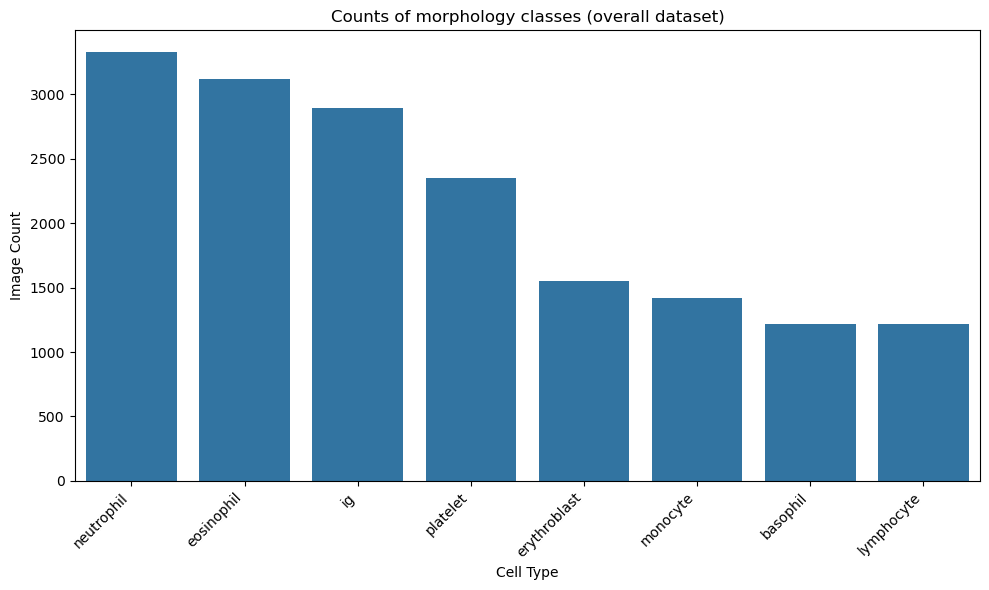

In [3]:


class_counts = {}

for subfolder in ROOT_DIR.iterdir():
    if not subfolder.is_dir():
        continue
    class_name = subfolder.name
    img_files = [
        f for f in subfolder.iterdir()
        if f.is_file() and f.suffix.lower() in IMG_EXTS
    ]
    class_counts[class_name] = len(img_files)

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["cell type", "count"]
)

df_counts = df_counts.sort_values("count", ascending=False).reset_index(drop=True)

df_counts["percentage"] = 100 * df_counts["count"] / df_counts["count"].sum()

print("\nClass distribution:")
print(df_counts.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=df_counts, x="cell type", y="count")
plt.title("Counts of morphology classes (overall dataset)")
plt.xlabel("Cell Type")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [5]:
pattern = re.compile(r'^([A-Za-z]+)_(\d+)\.jpg$')

rows = []
for dirpath, dirnames, filenames in os.walk(ROOT_DIR):
    for fname in filenames:
        m = pattern.match(fname)
        if not m:
            continue  
        abbrev = m.group(1)
        folder = Path(dirpath).name 
        rows.append({
            'filename': fname,
            'abb_class': abbrev,
            'folder': folder,
        })

df_NC = pd.DataFrame(rows, columns=['filename', 'abb_class', 'folder'])
df_NC.head()

,filename,abb_class,folder
0,BA_689200.jpg,BA,basophil
1,BA_883452.jpg,BA,basophil
2,BA_382161.jpg,BA,basophil
3,BA_175579.jpg,BA,basophil
4,BA_775722.jpg,BA,basophil


/var/folders/yb/0_1pj82935q25kz775_hfns40000gn/T/ipykernel_3643/1634243171.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_NC.groupby('abb_class').apply(lambda x: x.sample(n=3, random_state=42)).reset_index(drop=True)


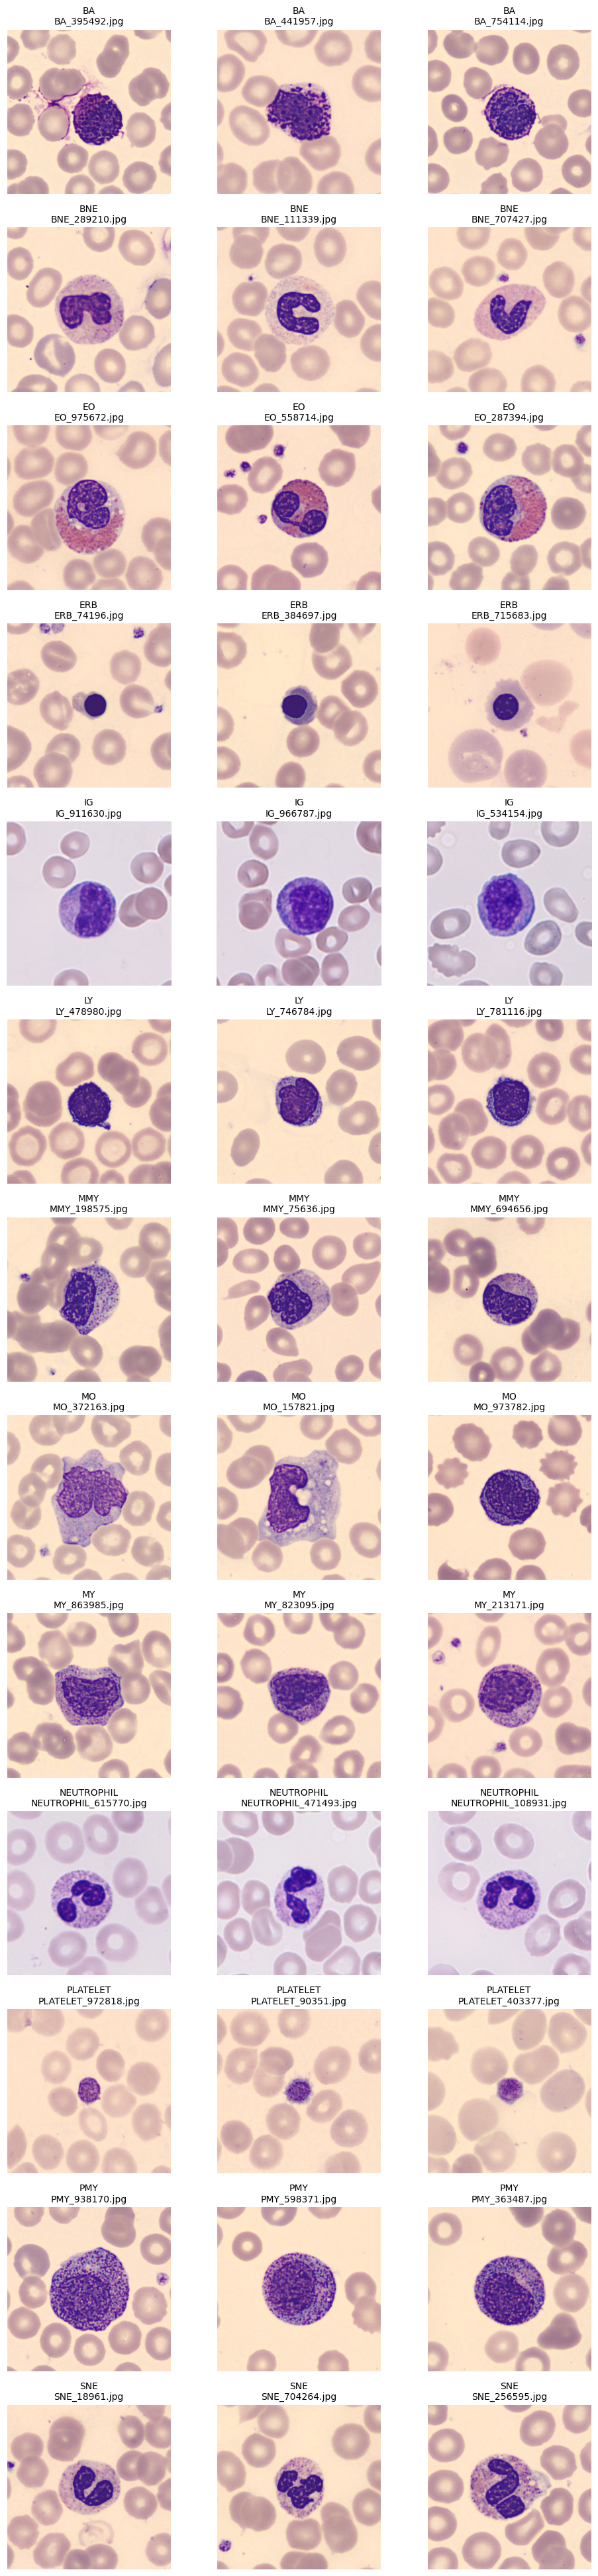

In [6]:

sampled_df = df_NC.groupby('abb_class').apply(lambda x: x.sample(n=3, random_state=42)).reset_index(drop=True)

classes = sampled_df['abb_class'].unique()
n_classes = len(classes)
fig, axes = plt.subplots(n_classes, 3, figsize=(10, 3 * n_classes))

if n_classes == 1:
    axes = axes.reshape(1, -1)

for i, cls in enumerate(classes):
    class_samples = sampled_df[sampled_df['abb_class'] == cls]
    
    for j, (_, row) in enumerate(class_samples.iterrows()):
        img_path = os.path.join(ROOT_DIR, row['folder'], row['filename'])
        
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].set_title(f"{row['abb_class']}\n{row['filename']}", fontsize=10)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [7]:


def analyze_image_rgb(img_path):
    try:
        img = Image.open(img_path)
        if img.mode != "RGB":
            img = img.convert("RGB")
        arr = np.array(img).astype(np.float32)  # [H, W, 3]

        gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
        mean_intensity = np.mean(gray)
        std_intensity = np.std(gray)

        r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
        stats = {
            "mean_r": np.mean(r),
            "std_r": np.std(r),
            "min_r": np.min(r),
            "max_r": np.max(r),
            "mean_g": np.mean(g),
            "std_g": np.std(g),
            "min_g": np.min(g),
            "max_g": np.max(g),
            "mean_b": np.mean(b),
            "std_b": np.std(b),
            "min_b": np.min(b),
            "max_b": np.max(b),
        }

        return mean_intensity, std_intensity, stats
    except Exception as e:
        print(f"Fehler beim Lesen von {img_path}: {e}")
        return np.nan, np.nan, {}


In [8]:

results = []

for class_name in os.listdir(ROOT_DIR):
    class_path = os.path.join(ROOT_DIR, class_name)
    if not os.path.isdir(class_path):
        continue

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff"))
    ]

    sampled_files = random.sample(
        image_files,
        min(MAX_IMAGES_PER_CLASS, len(image_files))
    )

    for img_file in sampled_files:
        img_path = os.path.join(class_path, img_file)
        mean_int, std_int, rgb_stats = analyze_image_rgb(img_path)

        row = {
            "class": class_name,
            "filename": img_file,
            "mean_intensity": mean_int,
            "std_intensity": std_int,
        }
        row.update(rgb_stats)
        results.append(row)


df = pd.DataFrame(results)







Fehler beim Lesen von /Users/moritz/__mk/_id/M/ref/dok/DataScientest/ProjectBloodCells/Data/NormalCells/PBC_dataset_normal_DIB/neutrophil/.DS_169665.jpg: cannot identify image file '/Users/moritz/__mk/_id/M/ref/dok/DataScientest/ProjectBloodCells/Data/NormalCells/PBC_dataset_normal_DIB/neutrophil/.DS_169665.jpg'


In [9]:

print("\nColor statistics per class (mean RGB values):")
print(df.groupby("class")[["mean_r", "mean_g", "mean_b"]].agg("mean"))


Color statistics per class (mean RGB values):
                  mean_r      mean_g      mean_b
class                                           
basophil      220.048263  187.953521  183.649320
eosinophil    222.176817  188.656194  182.449413
erythroblast  228.290703  198.276726  187.398531
ig            217.281036  185.661159  183.218722
lymphocyte    223.124070  191.674115  183.917446
monocyte      215.912685  183.868039  182.411102
neutrophil    222.146791  189.908148  182.974929
platelet      233.365231  202.296944  187.431526


In [10]:

df_rgb = df.groupby("class")[["mean_r", "mean_g", "mean_b"]].agg("mean").reset_index()
df_rgb.head()

,class,mean_r,mean_g,mean_b
0,basophil,220.048263,187.953521,183.649320
1,eosinophil,222.176817,188.656194,182.449413
2,erythroblast,228.290703,198.276726,187.398531
3,ig,217.281036,185.661159,183.218722
4,lymphocyte,223.124070,191.674115,183.917446


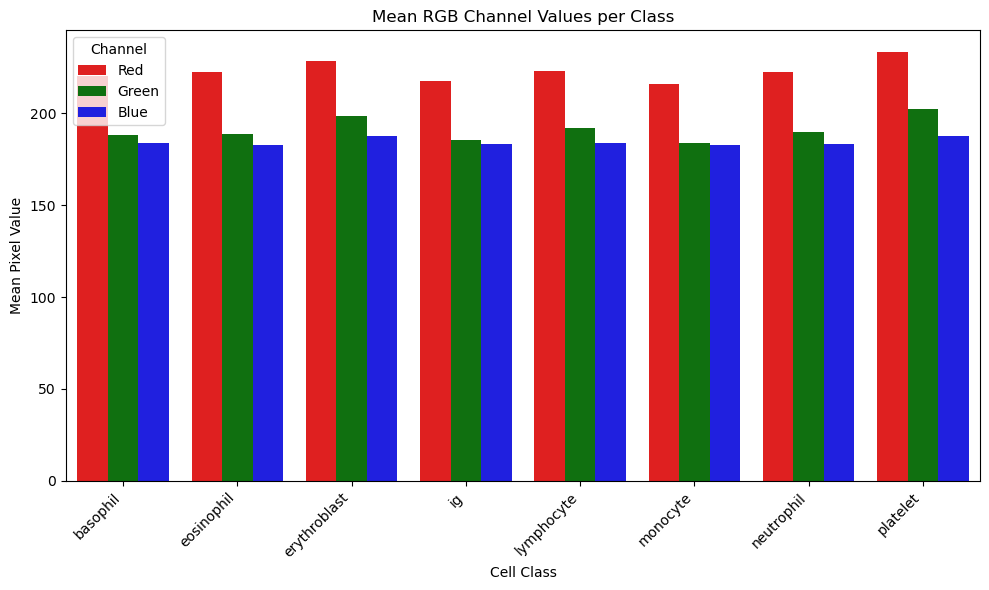

In [ ]:

df_long = pd.melt(
    df_rgb,
    id_vars="class",
    value_vars=["mean_r", "mean_g", "mean_b"],
    var_name="channel",
    value_name="mean_pixel_value"
)

df_long["channel"] = df_long["channel"].map(
    {"mean_r": "Red", "mean_g": "Green", "mean_b": "Blue"}
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="class",
    y="mean_pixel_value",
    hue="channel",
    palette=["red", "green", "blue"],
)
plt.title("Mean RGB Channel Values per Class")
plt.xlabel("Cell Class")
plt.ylabel("Mean Pixel Value")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Channel")
plt.tight_layout()
plt.show()

In [12]:
df_bc = df.groupby("class")[["mean_intensity", "std_intensity"]].agg("mean").reset_index()
df_bc.head()

,class,mean_intensity,std_intensity
0,basophil,197.059172,46.543409
1,eosinophil,197.971289,42.851977
2,erythroblast,206.010794,37.597438
3,ig,194.837066,46.342079
4,lymphocyte,200.193393,41.800940


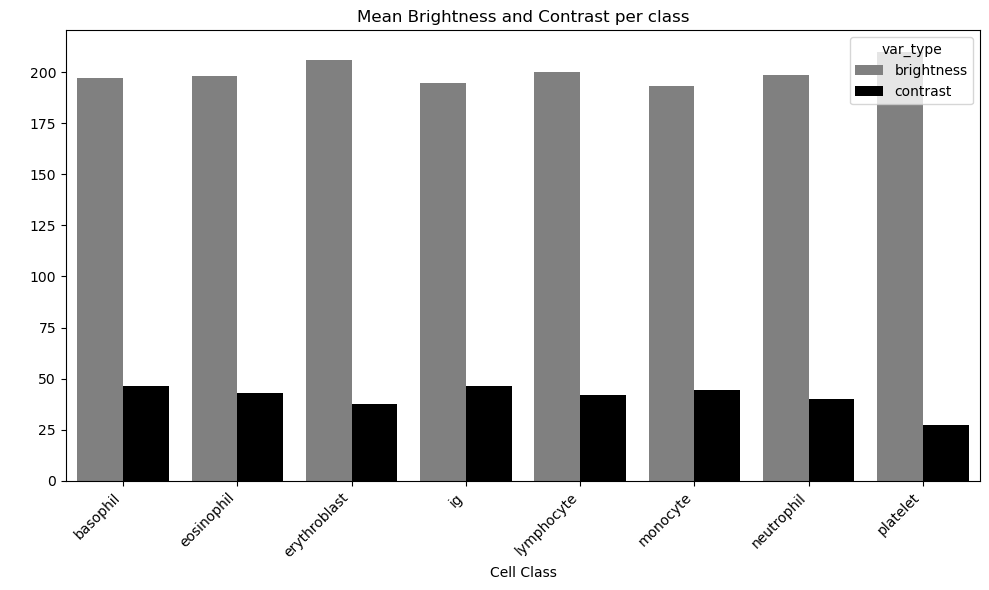

In [ ]:

df_long = pd.melt(
    df_bc,
    id_vars="class",
    value_vars=["mean_intensity", "std_intensity"],
    var_name="var_type",
    value_name="mean_pixel_value"
)

df_long["var_type"] = df_long["var_type"].map(
    {"mean_intensity": "brightness", "std_intensity": "contrast"}
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x="class",
    y="mean_pixel_value",
    hue="var_type",
    palette=["grey", "black"],
)
plt.title("Mean Brightness and Contrast per class")
plt.xlabel("Cell Class")
plt.ylabel(" ")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()